<a href="https://colab.research.google.com/github/Manojsv20/AI/blob/main/handwritten.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Handwritten digits recognition***

import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

loading the dataset

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
data = pd.DataFrame(mnist.data)
data['target'] = mnist.target
data.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [ ]:
data.shape

(70000, 785)

### Dataset Information

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel1 to target
dtypes: category(1), int64(784)
memory usage: 418.8 MB


### Descriptive Statistics

In [ ]:
display(data.describe())

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197414,0.099543,0.046629,0.016614,0.012957,0.001714,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.991206,4.256304,2.783732,1.561822,1.553796,0.320889,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


### Visualize a Random Digit

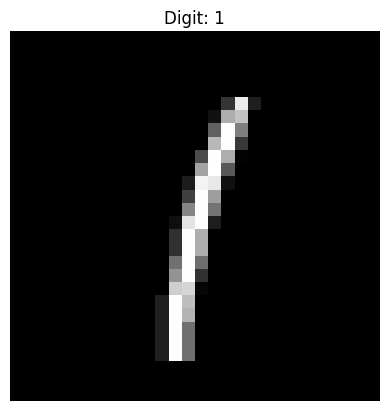

In [ ]:
# Select a random index
random_index = np.random.randint(0, len(data))

# Extract the image data (pixel values) and target label
# Exclude the 'target' column for image data
image_data = data.drop('target', axis=1).iloc[random_index].values
target_label = data['target'].iloc[random_index]

# Reshape the 1D array of pixel values into a 28x28 2D array
image = image_data.reshape(28, 28)

# Display the image
plt.imshow(image, cmap='gray')
plt.title(f"Digit: {target_label}")
plt.axis('off') # Hide axes
plt.show()

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target

print(X.shape)
print(y.shape)


(70000, 784)
(70000,)


In [ ]:
X = X / 255.0

In [ ]:
y=y.astype('int')

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

X_train = X_train.values.reshape(-1,28,28,1)
X_test = X_test.values.reshape(-1,28,28,1)

model = models.Sequential()

model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))


model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 60s 33ms/step - accuracy: 0.9546 - loss: 0.1527 - val_accuracy: 0.9759 - val_loss: 0.0779
Epoch 2/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - accuracy: 0.9849 - loss: 0.0504 - val_accuracy: 0.9845 - val_loss: 0.0480
Epoch 3/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9893 - loss: 0.0344 - val_accuracy: 0.9851 - val_loss: 0.0481
Epoch 4/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9915 - loss: 0.0264 - val_accuracy: 0.9877 - val_loss: 0.0392
Epoch 5/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 57s 32ms/step - accuracy: 0.9933 - loss: 0.0210 - val_accuracy: 0.9889 - val_loss: 0.0375


In [ ]:
validation_data=(X_test, y_test)

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:",round( accuracy*100,3) ,"%")

438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9889 - loss: 0.0375
Accuracy: 98.886 %


### Making Predictions

In [ ]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print("First 10 actual labels:", y_test.iloc[:10].tolist())
print("First 10 predicted labels:", predicted_classes[:10].tolist())

438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
First 10 actual labels: [8, 4, 8, 7, 7, 0, 6, 2, 7, 4]
First 10 predicted labels: [8, 4, 8, 7, 7, 0, 6, 2, 7, 4]


### Visualize Predictions

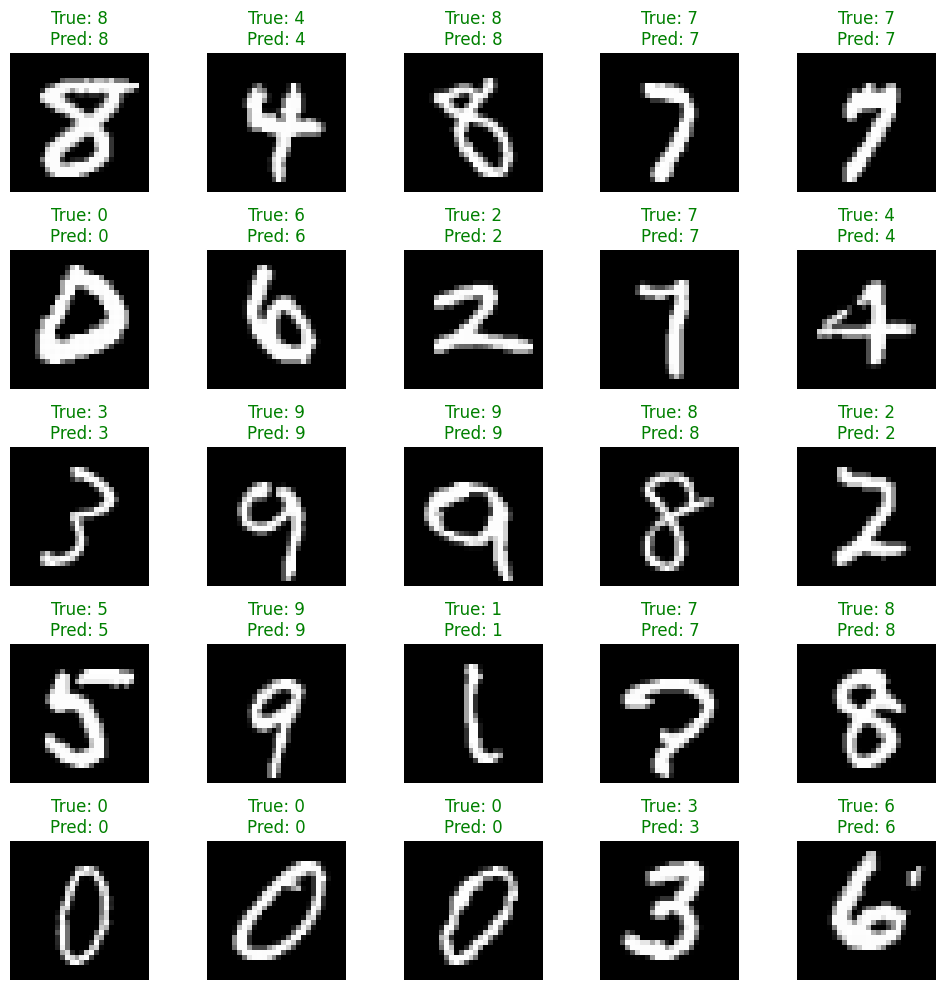

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(25): # Display first 25 test images
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test.iloc[i]}\nPred: {predicted_classes[i]}",
              color='green' if predicted_classes[i] == y_test.iloc[i] else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()